In [1]:
import pandas as pd

df = pd.read_csv("loan.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [5]:
# Numerical
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

# Categorical
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [6]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [7]:
# Total Income
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# EMI
df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']

# Debt-to-Income Ratio
df['DTI'] = df['LoanAmount'] / df['Total_Income']

# Drop ID
df = df.drop('Loan_ID', axis=1)

In [8]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,EMI,DTI
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0,0.355556,0.021884
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,0.355556,0.021015
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0.183333,0.022000
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,0.333333,0.024287
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,0.391667,0.023500


In [9]:
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

In [10]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [11]:
X = pd.get_dummies(X, drop_first=True)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
print(X_train.shape, X_test.shape)

(491, 17) (123, 17)


In [15]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [17]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("SVM:", accuracy_score(y_test, y_pred_svm))

Logistic Regression: 0.7804878048780488
Random Forest: 0.7886178861788617
SVM: 0.7967479674796748


In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)
print(cm)

[[18 25]
 [ 0 80]]


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       1.00      0.42      0.59        43
           1       0.76      1.00      0.86        80

    accuracy                           0.80       123
   macro avg       0.88      0.71      0.73       123
weighted avg       0.85      0.80      0.77       123



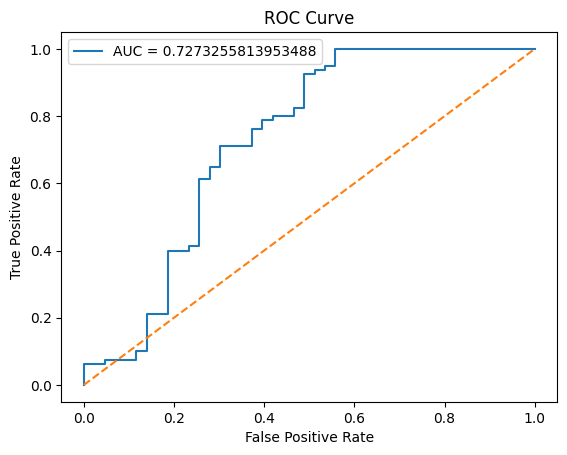

In [21]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = svm.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

print("Tuned Random Forest:", accuracy_score(y_test, y_pred_best))

Tuned Random Forest: 0.7967479674796748


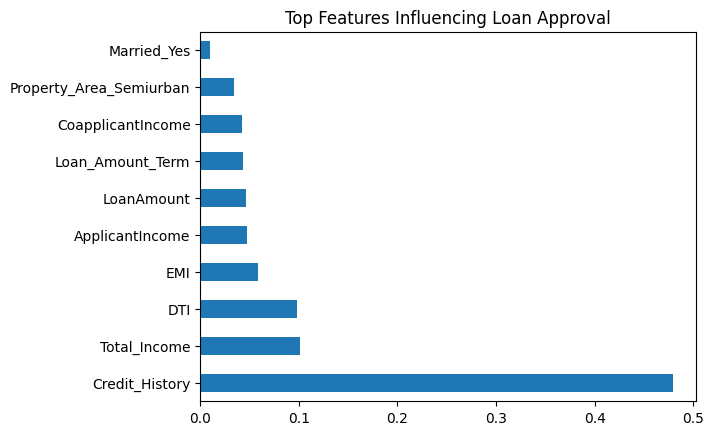

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

importances = best_rf.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features)
feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top Features Influencing Loan Approval")
plt.show()

In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_rf, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean CV score:", scores.mean())

Cross-validation scores: [0.80487805 0.7804878  0.79674797 0.83739837 0.80327869]
Mean CV score: 0.8045581767293083


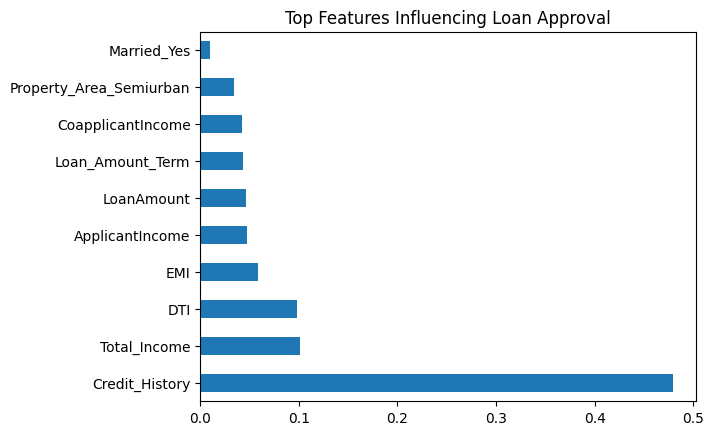

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

importances = best_rf.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features)
feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top Features Influencing Loan Approval")
plt.show()

In [27]:
rf_balanced = RandomForestClassifier(class_weight='balanced')
rf_balanced.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

In [28]:
test_df = pd.read_csv("test.csv")
test_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [29]:
# Fill missing values
test_df['LoanAmount'] = test_df['LoanAmount'].fillna(df['LoanAmount'].median())
test_df['Loan_Amount_Term'] = test_df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

test_df['Gender'] = test_df['Gender'].fillna(df['Gender'].mode()[0])
test_df['Married'] = test_df['Married'].fillna(df['Married'].mode()[0])
test_df['Dependents'] = test_df['Dependents'].fillna(df['Dependents'].mode()[0])
test_df['Self_Employed'] = test_df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
test_df['Credit_History'] = test_df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [30]:
test_df['Total_Income'] = test_df['ApplicantIncome'] + test_df['CoapplicantIncome']
test_df['EMI'] = test_df['LoanAmount'] / test_df['Loan_Amount_Term']
test_df['DTI'] = test_df['LoanAmount'] / test_df['Total_Income']

In [31]:
loan_ids = test_df['Loan_ID']
test_df = test_df.drop('Loan_ID', axis=1)

In [32]:
test_df = pd.get_dummies(test_df, drop_first=True)

# Align columns with training data
test_df = test_df.reindex(columns=X.columns, fill_value=0)

In [33]:
test_df = scaler.transform(test_df)

In [34]:
predictions = best_rf.predict(test_df)

In [35]:
predictions = ['Y' if p == 1 else 'N' for p in predictions]

In [36]:
output = pd.DataFrame({
    'Loan_ID': loan_ids,
    'Loan_Status': predictions
})

output.to_csv("submission.csv", index=False)

In [37]:
from sklearn.metrics import accuracy_score

print("Final Model Accuracy (Test Split):", accuracy_score(y_test, y_pred_best))

Final Model Accuracy (Test Split): 0.7967479674796748


In [38]:
import pandas as pd

# Count predictions
pred_counts = pd.Series(predictions).value_counts()

print("\nPrediction Summary (Unseen Data):")
print(pred_counts)


Prediction Summary (Unseen Data):
Y    304
N     63
Name: count, dtype: int64


In [39]:
output.head()

,Loan_ID,Loan_Status
0,LP001015,Y
1,LP001022,Y
2,LP001031,Y
3,LP001035,Y
4,LP001051,Y


In [40]:
total = len(predictions)

print("\nPrediction Distribution:")
for label, count in pred_counts.items():
    print(f"{label}: {count} ({(count/total)*100:.2f}%)")


Prediction Distribution:
Y: 304 (82.83%)
N: 63 (17.17%)
